In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
final_table = pd.read_csv("final_table.csv")
final_table.head()

,cluster,target,contig,SQ_gene_content_set,SQ_pathway,SQ_score,taxonomy,bitscore_list,evalue_list
0,63,"GCA_902754915.1_GLIGFB_00196,GCA_902754915.1_G...",CACVLH010000001.1,"sqiA,sqiK",sulfo-EMP,min,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,"[182.0, 185.0]","[7.299999999999999e-52, 4.5899999999999996e-55]"
1,66,"GCA_902754915.1_GLIGFB_00381,GCA_902754915.1_G...",CACVLH010000002.1,"sqvB,sqvD,sqwF,sqwG,sqwH,sqwI",sulfo-TK,min_up,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,"[142.0, 217.0, 162.0, 291.0, 298.0, 255.0]","[1.6599999999999999e-40, 5.99e-66, 3.31e-50, 1..."
2,271,"GCA_902755405.1_GNFANA_00528,GCA_902755405.1_G...",CACVMX010000032.1,"sqvA,sqwG,sqwH",sulfo-TAL,min,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,"[232.0, 227.0, 148.0]","[2.86e-74, 1.79e-71, 3.93e-43]"
3,387,"GCA_902755455.1_HAJFOH_00002,GCA_902755455.1_H...",CACVNO010000001.1,"sqiA,sqiK",sulfo-EMP,min,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,"[160.0, 182.0]","[1.03e-45, 7.299999999999999e-52]"
4,392,"GCA_902755455.1_HAJFOH_00507,GCA_902755455.1_H...",CACVNO010000004.1,"sqvD,sqwF,sqwG,sqwH,sqwI,yihQ",sulfo-TK,min_up,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,"[391.0, 275.0, 295.0, 292.0, 159.0, 206.0]","[1.12e-125, 1.51e-86, 3.47e-99, 8.999999999999..."


In [7]:
# Извлекаем phylum
final_table["phylum"] = final_table["taxonomy"].str.extract(r"p__([^;]+)")

# Считаем локусы для каждой пары путь/таксон и сортируем
taxa_counts = final_table.groupby(["SQ_pathway", "phylum"]).size().reset_index(name="count")
taxa_counts_sorted = taxa_counts.sort_values("count", ascending=False).reset_index(drop=True)

print(taxa_counts_sorted)

    SQ_pathway             phylum  count
0    sulfo-EMP          Bacillota    151
1    sulfo-TAL          Bacillota    150
2     sulfo-TK          Bacillota     50
3    sulfo-TAL     Actinomycetota     10
4    sulfo-TAL     Pseudomonadota      9
5    sulfo-EMP      Chloroflexota      8
6    sulfo-TAL   Thermoplasmatota      5
7   sulfo-ASMO     Actinomycetota      5
8    sulfo-EMP      Spirochaetota      4
9    sulfo-TAL      Chloroflexota      3
10    sulfo-TK      Spirochaetota      2
11   sulfo-EMP     Actinomycetota      2
12    sulfo-ED          Bacillota      1
13   sulfo-EMP  Verrucomicrobiota      1


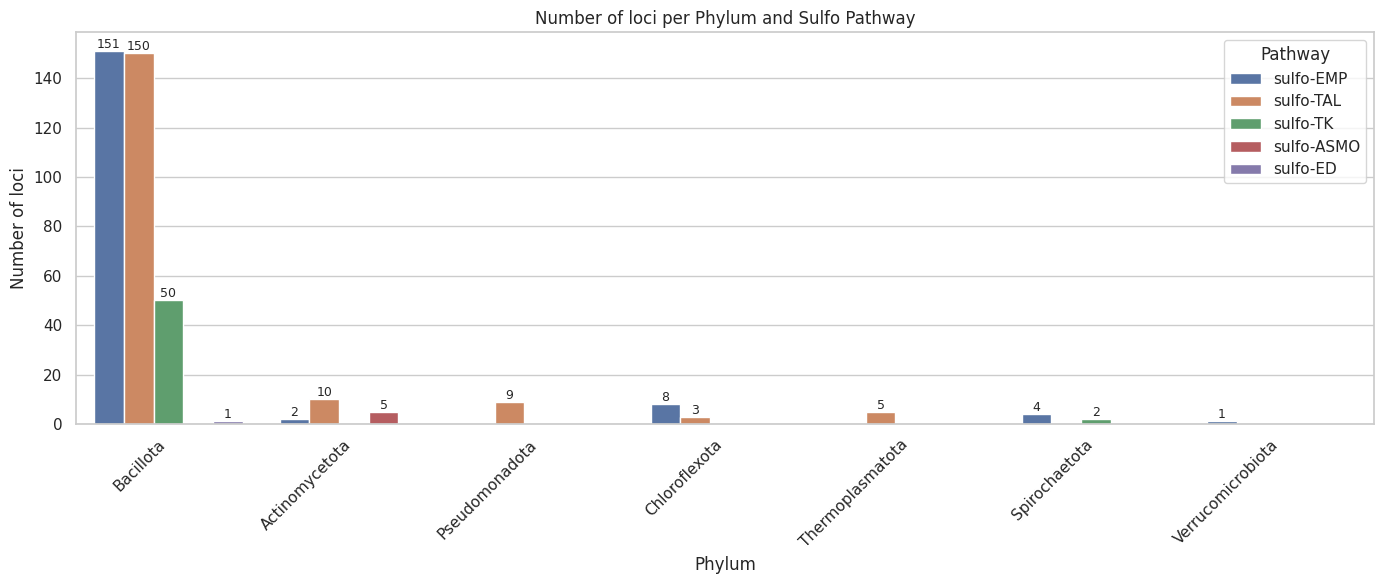

In [8]:
# Используем готовую таблицу со всеми count
plot_df = taxa_counts_sorted.copy()  # phylum, SQ_pathway, count

# Настройка графика
sns.set(style="whitegrid")
plt.figure(figsize=(14, 6))

# Столбцы: x = phylum, y = count, цвет = путь
ax = sns.barplot(data=plot_df, x="phylum", y="count", hue="SQ_pathway", dodge=True)

# Подписи значений Y над столбцами (только если count > 0)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{int(height)}',  # текст подписи
            (p.get_x() + p.get_width() / 2., height),  # координаты: центр и вершина столбца
            ha='center', va='bottom', fontsize=9
        )

# Настройка подписей осей и заголовка
plt.xticks(rotation=45, ha="right")
plt.xlabel("Phylum")
plt.ylabel("Number of loci")
plt.title("Number of loci per Phylum and Sulfo Pathway")
plt.legend(title="Pathway")
plt.tight_layout()

# --- Сохраняем график ---
plt.savefig("sulfo_pathways_by_phylum.png", dpi=300)  # PNG с высоким разрешением
# plt.savefig("sulfo_pathways_by_phylum.pdf")  # альтернатива PDF

plt.show()

In [9]:
# Извлекаем mag_id из target
final_table["mag_id"] = final_table["target"].str.extract(r"(GCA_\d+\.\d+)")

# Группируем по MAG
mag_summary = final_table.groupby("mag_id").agg({
    "SQ_pathway": lambda x: list(x.dropna()),
    "SQ_score": lambda x: list(x.dropna()),
    "taxonomy": "first"  # предполагаем, что таксономия одинаковая внутри MAG
}).reset_index()

# (опционально) убираем дубликаты путей внутри MAG
mag_summary["SQ_pathway"] = mag_summary["SQ_pathway"].apply(lambda x: list(set(x)))
mag_summary["SQ_score"] = mag_summary["SQ_score"].apply(lambda x: list(set(x)))

print(mag_summary)

              mag_id             SQ_pathway       SQ_score  \
0    GCA_902754915.1  [sulfo-EMP, sulfo-TK]  [min, min_up]   
1    GCA_902755405.1            [sulfo-TAL]          [min]   
2    GCA_902755455.1  [sulfo-EMP, sulfo-TK]  [min, min_up]   
3    GCA_902755505.1            [sulfo-EMP]          [max]   
4    GCA_902755545.1            [sulfo-TAL]          [min]   
..               ...                    ...            ...   
318  GCA_902803825.1            [sulfo-TAL]          [max]   
319  GCA_902803835.1            [sulfo-TAL]          [min]   
320  GCA_902804015.1            [sulfo-EMP]          [min]   
321  GCA_902804025.1            [sulfo-TAL]       [min_up]   
322  GCA_902804045.1            [sulfo-TAL]          [max]   

                                              taxonomy  
0    d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...  
1    d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...  
2    d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...  
3    d__Bacteria;p__Bacillo

In [10]:
# pathways (dict)
def make_pathway_dict(df):
    return dict(zip(df["SQ_pathway"], df["SQ_score"]))

mag_summary = final_table.groupby("mag_id").apply(make_pathway_dict).reset_index(name="pathways")

# добавим таксономию
taxonomy_map = final_table.groupby("mag_id")["taxonomy"].first().reset_index()
mag_summary = mag_summary.merge(taxonomy_map, on="mag_id")

print(mag_summary.head())

            mag_id                                    pathways  \
0  GCA_902754915.1  {'sulfo-EMP': 'min', 'sulfo-TK': 'min_up'}   
1  GCA_902755405.1                        {'sulfo-TAL': 'min'}   
2  GCA_902755455.1  {'sulfo-EMP': 'min', 'sulfo-TK': 'min_up'}   
3  GCA_902755505.1                        {'sulfo-EMP': 'max'}   
4  GCA_902755545.1                        {'sulfo-TAL': 'min'}   

                                            taxonomy  
0  d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...  
1  d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...  
2  d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...  
3  d__Bacteria;p__Bacillota;c__Clostridia;o__Lach...  
4  d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...  


/tmp/ipykernel_9153/809820822.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mag_summary = final_table.groupby("mag_id").apply(make_pathway_dict).reset_index(name="pathways")


In [11]:
# разворачиваем pathways в строки
rows = []
for _, row in mag_summary.iterrows():
    for pathway, score in row["pathways"].items():
        rows.append({
            "mag_id": row["mag_id"],
            "pathway": pathway,
            "score": score,
            "taxonomy": row["taxonomy"]
        })

long_df = pd.DataFrame(rows)

In [12]:
presence_matrix = pd.crosstab(long_df["mag_id"], long_df["pathway"])

In [13]:
score_map = {
    "min": 1,
    "min_up": 2,
    "min_down": 2,
    "max": 3
}

long_df["score_num"] = long_df["score"].map(score_map)

score_matrix = long_df.pivot_table(
    index="mag_id",
    columns="pathway",
    values="score_num",
    fill_value=0
)

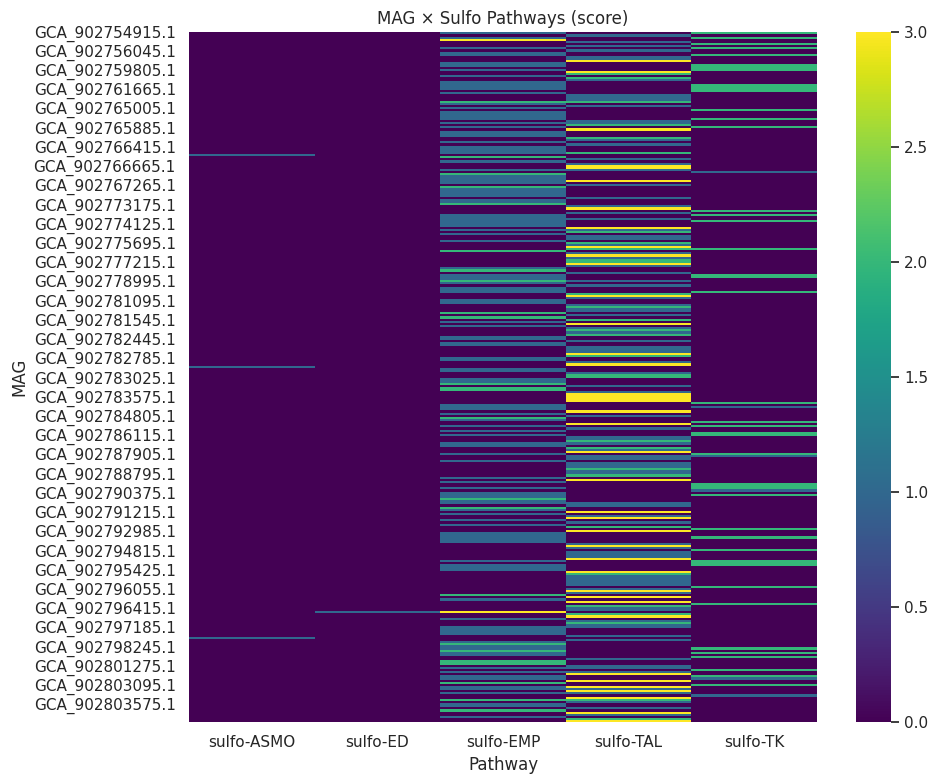

In [14]:
plt.figure(figsize=(10, 8))

sns.heatmap(score_matrix, cmap="viridis")

plt.title("MAG × Sulfo Pathways (score)")
plt.xlabel("Pathway")
plt.ylabel("MAG")
plt.tight_layout()

plt.savefig("heatmap_MAG_pathways.png", dpi=300)
plt.show()

In [15]:
long_df["phylum"] = long_df["taxonomy"].str.extract(r"p__([^;]+)")

In [16]:
phylum_counts = pd.crosstab(long_df["phylum"], long_df["pathway"])
print(phylum_counts)

pathway            sulfo-ASMO  sulfo-ED  sulfo-EMP  sulfo-TAL  sulfo-TK
phylum                                                                 
Actinomycetota              3         0          2          9         0
Bacillota                   0         1        143        138        50
Chloroflexota               0         0          4          3         0
Pseudomonadota              0         0          0          9         0
Spirochaetota               0         0          3          0         2
Thermoplasmatota            0         0          0          4         0
Verrucomicrobiota           0         0          1          0         0


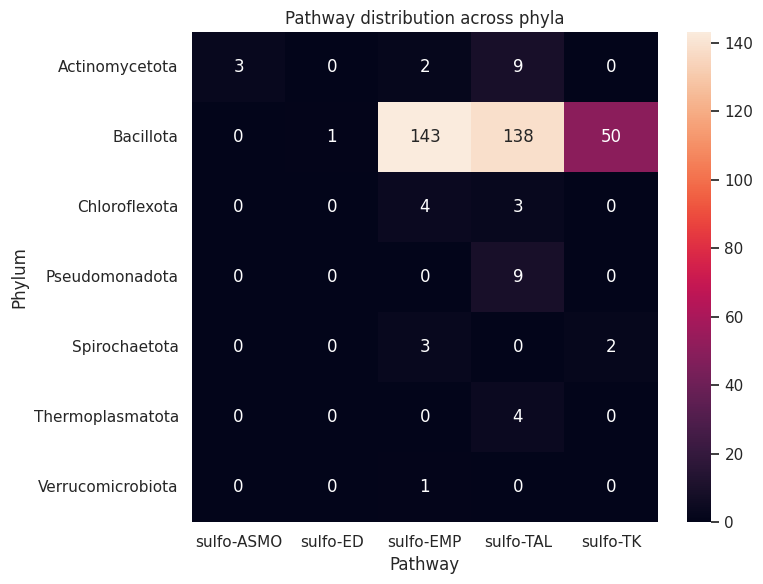

In [17]:
plt.figure(figsize=(8, 6))

sns.heatmap(phylum_counts, annot=True, fmt="d")

plt.title("Pathway distribution across phyla")
plt.xlabel("Pathway")
plt.ylabel("Phylum")

plt.tight_layout()
plt.savefig("heatmap_phylum_pathways.png", dpi=300)
plt.show()